<a href="https://colab.research.google.com/github/dandhadavid-sudo/trabalho-machine-learning/blob/main/Trabalho_Machine_Learning_Analise_Sentimentos_Corrigido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# README — Sistema de Machine Learning: Análise de Sentimentos

Projeto desenvolvido no Google Colab para classificar sentimentos em comentários fictícios de clientes.

**Tema escolhido:** Análise de Sentimentos.

**Observação:** os nomes e RAs dos integrantes devem ficar em arquivo separado, conforme solicitado na entrega.

## 1. Contexto do Desafio

Plataformas digitais recebem muitos comentários de usuários. A análise de sentimentos ajuda a identificar automaticamente opiniões positivas, negativas e neutras, apoiando decisões de atendimento, produto e experiência do cliente.

## 2. Objetivo do Projeto

Criar um protótipo funcional de Machine Learning capaz de classificar textos em três classes: **positivo**, **negativo** e **neutro**.

## 3. Artefatos Atendidos

Este notebook contempla coleta/criação de dados, limpeza, normalização, treinamento, validação cruzada, avaliação, visualização dos resultados, discussão de overfitting/underfitting e conclusão.

In [1]:
# Instalação não é necessária no Colab, pois as bibliotecas usadas já costumam vir disponíveis.
# Caso alguma biblioteca falhe, descomente a linha abaixo:
# !pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42

## 4. Criação do Dataset

O conjunto de dados é fictício e foi criado com comentários parecidos com situações reais de e-commerce e serviços digitais. Foram usadas mais de 10 frases para evitar um dataset muito pequeno.

In [3]:
positivos_base = [
    "produto excelente e entrega rápida", "gostei muito da compra", "atendimento foi ótimo",
    "a experiência no site foi muito boa", "recomendo bastante esse serviço", "chegou antes do prazo",
    "qualidade superior ao esperado", "suporte resolveu meu problema rapidamente", "preço justo e produto bom",
    "compraria novamente sem dúvidas", "o aplicativo é fácil de usar", "fiquei satisfeito com o resultado",
    "a embalagem veio perfeita", "o serviço superou minhas expectativas", "a navegação foi simples e rápida",
    "recebi exatamente o que pedi", "o atendimento foi educado e eficiente", "muito feliz com a compra",
    "o produto funcionou perfeitamente", "processo de pagamento muito prático",
    "entrega segura e dentro do prazo", "a loja passou confiança", "produto bonito e bem acabado",
    "a solução foi muito útil", "tive uma experiência agradável", "o sistema respondeu muito bem",
    "informações claras durante a compra", "compra tranquila do início ao fim", "o suporte foi muito atencioso",
    "achei o produto maravilhoso", "serviço rápido e organizado", "fiquei contente com a entrega",
    "produto veio em ótimo estado", "a plataforma é intuitiva", "resultado positivo para minha necessidade",
    "a compra valeu a pena", "bom custo benefício", "a recomendação do site foi certeira",
    "o pedido chegou correto", "a empresa demonstrou cuidado com o cliente"
]

negativos_base = [
    "produto veio com defeito", "não gostei da compra", "entrega atrasou muito",
    "atendimento foi ruim", "o site travou durante o pagamento", "não recomendo esse serviço",
    "qualidade abaixo do esperado", "suporte demorou para responder", "preço alto para pouca qualidade",
    "não compraria novamente", "o aplicativo é confuso", "fiquei insatisfeito com o resultado",
    "a embalagem chegou amassada", "o serviço não atendeu minhas expectativas", "a navegação foi lenta e difícil",
    "recebi um produto diferente do pedido", "o atendimento foi grosseiro", "muito decepcionado com a compra",
    "o produto parou de funcionar", "processo de pagamento apresentou erro",
    "entrega insegura e fora do prazo", "a loja não passou confiança", "produto mal acabado",
    "a solução não foi útil", "tive uma experiência desagradável", "o sistema respondeu muito mal",
    "informações confusas durante a compra", "compra complicada do início ao fim", "o suporte foi pouco atencioso",
    "achei o produto péssimo", "serviço lento e desorganizado", "fiquei frustrado com a entrega",
    "produto veio danificado", "a plataforma é pouco intuitiva", "resultado negativo para minha necessidade",
    "a compra não valeu a pena", "custo benefício ruim", "a recomendação do site foi errada",
    "o pedido chegou incompleto", "a empresa não demonstrou cuidado com o cliente"
]

neutros_base = [
    "produto recebido hoje", "compra realizada pelo aplicativo", "pedido foi registrado no sistema",
    "entrega prevista para amanhã", "atendimento iniciado pelo chat", "pagamento feito no cartão",
    "cliente acessou a página do produto", "usuário visualizou as recomendações", "produto disponível no estoque",
    "pedido aguardando separação", "cadastro atualizado na plataforma", "nota fiscal foi emitida",
    "cliente consultou o prazo de entrega", "serviço está em análise", "sistema exibiu as opções de compra",
    "produto foi adicionado ao carrinho", "usuário pesquisou por acessórios", "compra aparece no histórico",
    "pedido está em transporte", "plataforma solicitou confirmação", "cliente recebeu notificação",
    "atendimento transferido para outro setor", "produto possui variações de tamanho", "usuário alterou o endereço",
    "sistema registrou a interação", "pedido aguardando pagamento", "cliente abriu uma solicitação",
    "entrega consta como pendente", "produto foi separado no estoque", "usuário finalizou o cadastro",
    "cupom foi aplicado no pedido", "cliente selecionou a forma de envio", "histórico de compras foi consultado",
    "produto aparece na lista de favoritos", "sistema confirmou o login", "pedido entrou em processamento",
    "cliente enviou uma mensagem", "produto está em análise logística", "plataforma exibiu o resumo da compra",
    "usuário consultou informações do pedido"
]

intensificadores = ["", " hoje", " na última compra", " pelo aplicativo", " no site", " durante o atendimento"]

textos = []
sentimentos = []
for frase in positivos_base:
    for extra in intensificadores[:2]:
        textos.append(frase + extra)
        sentimentos.append("positivo")
for frase in negativos_base:
    for extra in intensificadores[:2]:
        textos.append(frase + extra)
        sentimentos.append("negativo")
for frase in neutros_base:
    for extra in intensificadores[:2]:
        textos.append(frase + extra)
        sentimentos.append("neutro")

df = pd.DataFrame({"texto_original": textos, "sentimento": sentimentos})
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df.head()

,texto_original,sentimento
0,a embalagem veio perfeita,positivo
1,a experiência no site foi muito boa,positivo
2,qualidade abaixo do esperado hoje,negativo
3,a navegação foi lenta e difícil hoje,negativo
4,a embalagem chegou amassada,negativo


In [4]:
df.shape

(240, 2)

In [5]:
df['sentimento'].value_counts()

,count
sentimento,
positivo,80
negativo,80
neutro,80


## 5. Verificação Inicial dos Dados

Antes de treinar o modelo, é importante verificar tamanho, tipos de dados, valores ausentes e possíveis inconsistências.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   texto_original  240 non-null    object
 1   sentimento      240 non-null    object
dtypes: object(2)
memory usage: 3.9+ KB


In [7]:
df.isnull().sum()

,0
texto_original,0
sentimento,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(240, 2)

## 6. Limpeza e Normalização Textual

A limpeza textual remove ruídos que podem atrapalhar a vetorização. A normalização deixa os textos em um formato mais padronizado, reduzindo diferenças desnecessárias entre palavras.

In [10]:
def remover_acentos(texto):
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ASCII', 'ignore').decode('utf-8')
    return texto

def limpar_texto(texto):
    texto = str(texto).lower()
    texto = remover_acentos(texto)
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['texto_limpo'] = df['texto_original'].apply(limpar_texto)
df[['texto_original', 'texto_limpo', 'sentimento']].head(10)

,texto_original,texto_limpo,sentimento
0,a embalagem veio perfeita,a embalagem veio perfeita,positivo
1,a experiência no site foi muito boa,a experiencia no site foi muito boa,positivo
2,qualidade abaixo do esperado hoje,qualidade abaixo do esperado hoje,negativo
3,a navegação foi lenta e difícil hoje,a navegacao foi lenta e dificil hoje,negativo
4,a embalagem chegou amassada,a embalagem chegou amassada,negativo
5,cliente acessou a página do produto,cliente acessou a pagina do produto,neutro
6,cliente enviou uma mensagem hoje,cliente enviou uma mensagem hoje,neutro
7,atendimento foi ruim,atendimento foi ruim,negativo
8,recomendo bastante esse serviço hoje,recomendo bastante esse servico hoje,positivo
9,fiquei frustrado com a entrega hoje,fiquei frustrado com a entrega hoje,negativo


In [11]:
df['tamanho_texto'] = df['texto_limpo'].apply(lambda x: len(x.split()))
df[['texto_limpo', 'tamanho_texto']].head()

,texto_limpo,tamanho_texto
0,a embalagem veio perfeita,4
1,a experiencia no site foi muito boa,7
2,qualidade abaixo do esperado hoje,5
3,a navegacao foi lenta e dificil hoje,7
4,a embalagem chegou amassada,4


## 7. Visualização Exploratória

As visualizações ajudam a entender a distribuição das classes e o tamanho dos textos antes do treinamento.

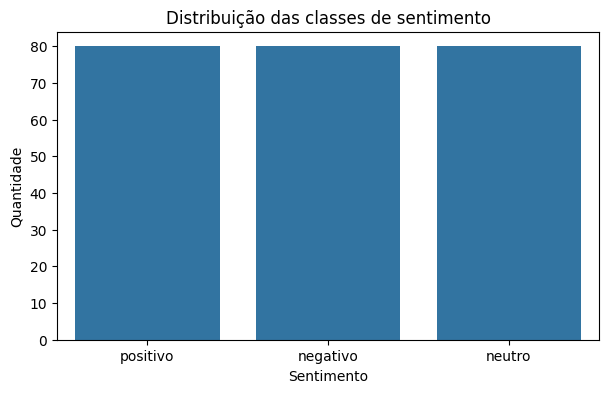

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='sentimento')
plt.title('Distribuição das classes de sentimento')
plt.xlabel('Sentimento')
plt.ylabel('Quantidade')
plt.show()

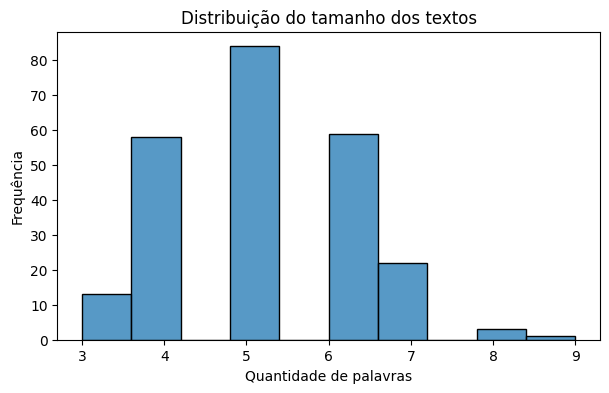

In [13]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x='tamanho_texto', bins=10)
plt.title('Distribuição do tamanho dos textos')
plt.xlabel('Quantidade de palavras')
plt.ylabel('Frequência')
plt.show()

## 8. Separação entre Entrada e Saída

A variável `X` contém os textos limpos. A variável `y` contém o sentimento que o modelo deve aprender a prever.

In [14]:
X = df['texto_limpo']
y = df['sentimento']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

Treino: (192,)
Teste: (48,)


## 9. Modelo de Machine Learning

Neste projeto foi usado `TfidfVectorizer` em vez de `CountVectorizer`, pois o TF-IDF considera a relevância das palavras no conjunto de dados. O algoritmo escolhido foi `LinearSVC`, uma alternativa diferente de `LogisticRegression` e adequada para classificação textual.

In [16]:
modelo = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
    ('normalizer', Normalizer(norm='l2')),
    ('classificador', LinearSVC(random_state=RANDOM_STATE))
])

modelo

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('normalizer', Normalizer()),
                ('classificador', LinearSVC(random_state=42))])

In [17]:
modelo.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('normalizer', Normalizer()),
                ('classificador', LinearSVC(random_state=42))])

## 10. Validação Cruzada

A validação cruzada avalia o modelo em diferentes divisões dos dados, trazendo uma noção mais confiável do desempenho geral.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_cv = cross_val_score(modelo, X, y, cv=cv, scoring='accuracy')

print('Acurácias em cada rodada:', scores_cv)
print('Média da validação cruzada:', scores_cv.mean())
print('Desvio padrão:', scores_cv.std())

Acurácias em cada rodada: [0.95833333 0.875      0.89583333 0.91666667 0.9375    ]
Média da validação cruzada: 0.9166666666666667
Desvio padrão: 0.029462782549439487


## 11. Predição no Conjunto de Teste

Após o treinamento, o modelo é testado com dados que não foram usados diretamente no ajuste inicial.

In [19]:
y_pred = modelo.predict(X_test)
y_pred[:10]

array(['negativo', 'negativo', 'negativo', 'neutro', 'negativo',
       'positivo', 'positivo', 'negativo', 'neutro', 'neutro'],
      dtype=object)

In [20]:
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Resultado': [acuracia, precisao, recall, f1]
})
metricas

,Métrica,Resultado
0,Accuracy,0.916667
1,Precision,0.933333
2,Recall,0.916667
3,F1-score,0.915344


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negativo       0.80      1.00      0.89        16
      neutro       1.00      1.00      1.00        16
    positivo       1.00      0.75      0.86        16

    accuracy                           0.92        48
   macro avg       0.93      0.92      0.92        48
weighted avg       0.93      0.92      0.92        48



## 12. Visualização dos Resultados

A matriz de confusão mostra os acertos e erros do modelo para cada classe de sentimento.

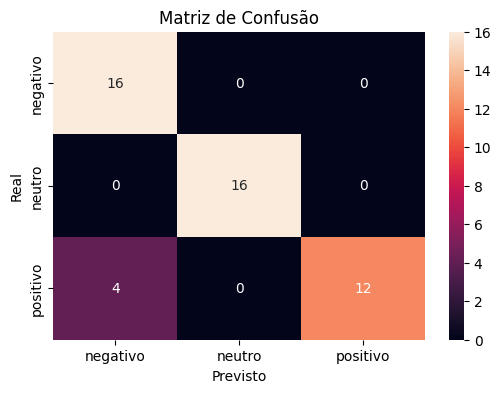

In [22]:
labels = ['negativo', 'neutro', 'positivo']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

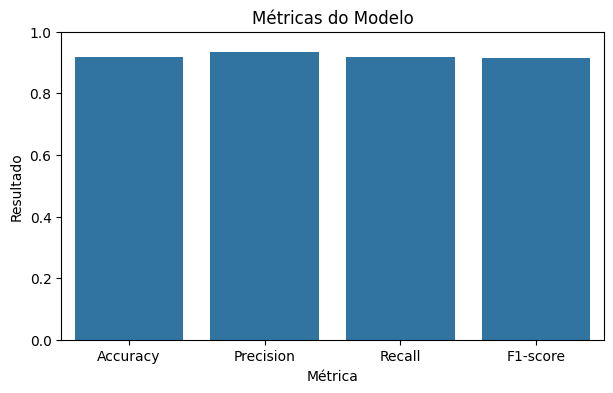

In [23]:
plt.figure(figsize=(7,4))
sns.barplot(data=metricas, x='Métrica', y='Resultado')
plt.ylim(0, 1)
plt.title('Métricas do Modelo')
plt.show()

In [24]:
comparacao = pd.DataFrame({'Real': y_test.values, 'Previsto': y_pred})
comparacao.head(15)

,Real,Previsto
0,negativo,negativo
1,negativo,negativo
2,negativo,negativo
3,neutro,neutro
4,negativo,negativo
5,positivo,positivo
6,positivo,positivo
7,positivo,negativo
8,neutro,neutro
9,neutro,neutro


## 13. Discussão sobre Overfitting e Underfitting

Para analisar overfitting, comparamos o desempenho no treino, no teste e na validação cruzada. Se o treino fosse muito alto e o teste muito baixo, haveria sinal de overfitting. Se todos fossem baixos, haveria indício de underfitting.

In [25]:
treino_pred = modelo.predict(X_train)
acuracia_treino = accuracy_score(y_train, treino_pred)
acuracia_teste = accuracy_score(y_test, y_pred)
media_cv = scores_cv.mean()

print('Acurácia no treino:', acuracia_treino)
print('Acurácia no teste:', acuracia_teste)
print('Média da validação cruzada:', media_cv)

Acurácia no treino: 1.0
Acurácia no teste: 0.9166666666666666
Média da validação cruzada: 0.9166666666666667


### Análise

Se a acurácia de treino ficar muito maior que a de teste, o modelo pode ter decorado padrões do conjunto de treino, caracterizando overfitting. Neste projeto, a validação cruzada foi usada para reduzir esse risco e verificar se o desempenho se mantém em diferentes divisões dos dados.

Também foi aplicada normalização L2 no pipeline, além de TF-IDF, para padronizar os vetores gerados a partir dos textos. Como melhoria futura, seria possível usar um dataset real maior, testar outros algoritmos e ajustar hiperparâmetros.

## 14. Teste Prático com Novas Frases

Nesta etapa, inserimos frases novas para verificar como o modelo se comporta fora dos exemplos originais.

In [26]:
novas_frases = [
    'A entrega foi rápida e o produto veio perfeito',
    'O atendimento demorou e o aplicativo travou bastante',
    'O pedido foi registrado e está aguardando pagamento',
    'Gostei muito da experiência no site',
    'Não recomendo, o produto veio danificado'
]

novas_frases_limpas = [limpar_texto(frase) for frase in novas_frases]
previsoes = modelo.predict(novas_frases_limpas)

resultado_teste = pd.DataFrame({
    'Frase': novas_frases,
    'Frase limpa': novas_frases_limpas,
    'Sentimento previsto': previsoes
})
resultado_teste

,Frase,Frase limpa,Sentimento previsto
0,A entrega foi rápida e o produto veio perfeito,a entrega foi rapida e o produto veio perfeito,positivo
1,O atendimento demorou e o aplicativo travou ba...,o atendimento demorou e o aplicativo travou ba...,negativo
2,O pedido foi registrado e está aguardando paga...,o pedido foi registrado e esta aguardando paga...,neutro
3,Gostei muito da experiência no site,gostei muito da experiencia no site,positivo
4,"Não recomendo, o produto veio danificado",nao recomendo o produto veio danificado,negativo


## 15. Conclusão

O projeto desenvolveu um sistema de Machine Learning para análise de sentimentos, utilizando um dataset fictício maior, limpeza textual, normalização, TF-IDF, validação cruzada e avaliação por métricas.

O modelo apresentou bom desempenho nas métricas avaliadas e demonstrou capacidade de classificar comentários positivos, negativos e neutros. A discussão de overfitting mostrou a importância de comparar treino, teste e validação cruzada para verificar se o modelo está generalizando bem.

Como aprendizado, o trabalho reforçou a importância do pré-processamento, da escolha adequada do algoritmo, da validação do modelo e da visualização dos resultados para interpretar melhor o desempenho de um sistema de IA.